In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
PROJECT_DIR = Path("../")

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

TRAIN_PATH = RAW_DATA_DIR / "train.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project exists:", PROJECT_DIR.exists())
print("Train exists:", TRAIN_PATH.exists())
print("Processed dir exists:", PROCESSED_DATA_DIR.exists())

Project exists: True
Train exists: True
Processed dir exists: True


In [3]:
train_df = pd.read_csv(TRAIN_PATH)

print("Train shape:", train_df.shape)
display(train_df.head())
print("Columns:", train_df.columns.tolist())

Train shape: (9500, 3)


,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",wizard creates secret


Columns: ['id', 'prompt', 'answer']


In [4]:
def find_column(df, possible_names):
    columns_lower = {col.lower(): col for col in df.columns}
    
    for name in possible_names:
        if name.lower() in columns_lower:
            return columns_lower[name.lower()]
    
    return None


prompt_col = find_column(
    train_df,
    ["prompt", "question", "puzzle", "input", "problem"]
)

answer_col = find_column(
    train_df,
    ["answer", "target", "output", "solution", "label"]
)

print("Prompt column:", prompt_col)
print("Answer column:", answer_col)

if prompt_col is None:
    raise ValueError(f"Could not find prompt column. Columns: {train_df.columns.tolist()}")

if answer_col is None:
    raise ValueError(f"Could not find answer column. Columns: {train_df.columns.tolist()}")

Prompt column: prompt
Answer column: answer


In [5]:
real_df = train_df[[prompt_col, answer_col]].copy()
real_df.columns = ["prompt", "answer"]

real_df["prompt"] = real_df["prompt"].astype(str).str.strip()
real_df["answer"] = real_df["answer"].astype(str).str.strip()

real_df = real_df.dropna()
real_df = real_df.drop_duplicates()

real_df["source"] = "official"

print("Clean official shape:", real_df.shape)
display(real_df.head())

Clean official shape: (9500, 3)


,prompt,answer,source
0,"In Alice's Wonderland, a secret bit manipulati...",10010111,official
1,"In Alice's Wonderland, a secret bit manipulati...",01000011,official
2,"In Alice's Wonderland, secret encryption rules...",cat imagines book,official
3,"In Alice's Wonderland, numbers are secretly co...",XXXVIII,official
4,"In Alice's Wonderland, secret encryption rules...",wizard creates secret,official


In [6]:
pd.set_option("display.max_colwidth", 1000)

display(real_df.sample(min(10, len(real_df)), random_state=42))

,prompt,answer,source
952,"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01001000 -> 10100100\n00011100 -> 11001110\n01001001 -> 10110100\n00011111 -> 11111111\n01000100 -> 01100010\n01010110 -> 01001011\n11000101 -> 00110010\n10010101 -> 00011010\n00000100 -> 01000010\n\nNow, determine the output for: 00101111",11100111,official
6599,"In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n<[+&< = <[&<\n)&*#) = ){}}\n}{+{\ = }{{\\n{\*#} = {@#{\n{&*^< = )[<<\nNow, determine the result for: \&+[[",\&[[,official
4220,"In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n99 -> XCIX\n15 -> XV\n73 -> LXXIII\nNow, write the number 25 in the Wonderland numeral system.",XXV,official
2554,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n26.92 m becomes 37.82\n38.94 m becomes 54.71\n34.29 m becomes 48.18\nNow, convert the following measurement: 14.75 m",20.72,official
4519,"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n10100110 -> 01111010\n11101010 -> 01001111\n01111110 -> 00100000\n11011010 -> 01011011\n11001111 -> 11010100\n00010101 -> 10001111\n11000010 -> 01010001\n10100000 -> 01111000\n11001001 -> 11010110\n00010011 -> 10001101\n\nNow, determine the output for: 00110111",10010110,official
1557,"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01001011 -> 01100111\n00100000 -> 01111101\n11111011 -> 10101111\n00010010 -> 10010110\n11000101 -> 10110111\n10101101 -> 10010011\n00000100 -> 10101111\n\nNow, determine the output for: 11011001",00000111,official
7945,"In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n&&]{> = "":]\n>&*%| = &/{{\n$!]$& = /$\nNow, determine the result for: %&#$>","{/""",official
4667,"In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n91 -> XCI\n94 -> XCIV\n1 -> I\n95 -> XCV\nNow, write the number 56 in the Wonderland numeral system.",LVI,official
7697,"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01111000 -> 11011100\n10111100 -> 10101110\n10101000 -> 11110100\n10111000 -> 10111100\n00000011 -> 00001101\n11011111 -> 00010011\n01000110 -> 00111011\n11100111 -> 11101111\n10011011 -> 00100001\n11011100 -> 00011110\n\nNow, determine the output for: 10000000",01000000,official
8928,"In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nlqgnbqj qafecjqo gschq hveegtq -> teacher explores above village\npvwgjm oqqo rymqj hveegtq -> wizard sees under village\nolrmqyl njqglqo lbq oljgytq frwweq -> student creates the strange puzzle\nxvyt pglnbqo rymqj pcymqjegym -> king watches under wonderland\nlqgnbqj njqglqo lbq oqnjql ljqgorjq -> teacher creates the secret treasure\nNow, decrypt the following text: pvwgjm zceecpo vyovmq pcymqjegym",wizard follows inside wonderland,official


In [7]:
SYMBOLS = list("$?<>`\\{@):;#%&*![]{}+-=/|~^_")

random.seed(42)
np.random.seed(42)

print("Number of symbols:", len(SYMBOLS))
print(SYMBOLS)

Number of symbols: 28
['$', '?', '<', '>', '`', '\\', '{', '@', ')', ':', ';', '#', '%', '&', '*', '!', '[', ']', '{', '}', '+', '-', '=', '/', '|', '~', '^', '_']


### Basic Synthetic rule class

In [8]:
class PuzzleRule:
    def __init__(self, name, transform_func):
        self.name = name
        self.transform_func = transform_func

    def apply(self, text):
        return self.transform_func(text)

### define rules

In [10]:
def remove_first_char(text):
    return text[1:] if len(text) > 1 else text


def remove_last_char(text):
    return text[:-1] if len(text) > 1 else text


def duplicate_first_char(text):
    return text[0] + text if len(text) > 0 else text


def duplicate_last_char(text):
    return text + text[-1] if len(text) > 0 else text


def swap_first_two(text):
    if len(text) < 2:
        return text
    return text[1] + text[0] + text[2:]


def swap_last_two(text):
    if len(text) < 2:
        return text
    return text[:-2] + text[-1] + text[-2]


def reverse_text(text):
    return text[::-1]


def remove_middle_char(text):
    if len(text) < 3:
        return text
    mid = len(text) // 2
    return text[:mid] + text[mid + 1:]


simple_rules = [
    PuzzleRule("remove_first_char", remove_first_char),
    PuzzleRule("remove_last_char", remove_last_char),
    PuzzleRule("duplicate_first_char", duplicate_first_char),
    PuzzleRule("duplicate_last_char", duplicate_last_char),
    PuzzleRule("swap_first_two", swap_first_two),
    PuzzleRule("swap_last_two", swap_last_two),
    PuzzleRule("reverse_text", reverse_text),
    PuzzleRule("remove_middle_char", remove_middle_char),
]

print("Simple rules:", len(simple_rules))

Simple rules: 8


### Define replacement rules

In [11]:
def replace_symbol_factory(old, new):
    def replace_symbol(text):
        return text.replace(old, new)
    return replace_symbol


replacement_rules = []

for old in SYMBOLS:
    for new in SYMBOLS:
        if old != new:
            replacement_rules.append(
                PuzzleRule(
                    f"replace_{old}_with_{new}",
                    replace_symbol_factory(old, new)
                )
            )

print("Replacement rules:", len(replacement_rules))

Replacement rules: 754


### Define Positional rules

In [12]:
def replace_first_char_factory(new):
    def replace_first_char(text):
        if len(text) == 0:
            return text
        return new + text[1:]
    return replace_first_char


def replace_last_char_factory(new):
    def replace_last_char(text):
        if len(text) == 0:
            return text
        return text[:-1] + new
    return replace_last_char


position_rules = []

for symbol in SYMBOLS:
    position_rules.append(
        PuzzleRule(
            f"replace_first_with_{symbol}",
            replace_first_char_factory(symbol)
        )
    )
    
    position_rules.append(
        PuzzleRule(
            f"replace_last_with_{symbol}",
            replace_last_char_factory(symbol)
        )
    )

print("Position rules:", len(position_rules))

Position rules: 56


### Combine Rules

In [13]:
rules = simple_rules + replacement_rules + position_rules

print("Total rules:", len(rules))

Total rules: 818


### Random String generator

In [14]:
def random_string(min_len=4, max_len=8):
    length = random.randint(min_len, max_len)
    return "".join(random.choice(SYMBOLS) for _ in range(length))

### Create syntthethetic puzzle

In [15]:
def make_puzzle(num_examples=4):
    rule = random.choice(rules)

    examples = []
    used_inputs = set()

    attempts = 0

    while len(examples) < num_examples and attempts < 100:
        attempts += 1

        x = random_string()
        y = rule.apply(x)

        if x in used_inputs:
            continue

        if y == x:
            continue

        used_inputs.add(x)
        examples.append((x, y))

    if len(examples) < num_examples:
        return None

    target = random_string()
    answer = rule.apply(target)

    if answer == target:
        return None

    prompt_lines = []
    for x, y in examples:
        prompt_lines.append(f"{x} = {y}")

    prompt = "\n".join(prompt_lines)
    prompt += f"\nNow, determine the result for: {target}"

    return {
        "prompt": prompt,
        "answer": answer,
        "rule": rule.name,
        "source": "synthetic"
    }

### Generate synthetic Data

In [16]:
NUM_SYNTHETIC = 5000

synthetic_rows = []

while len(synthetic_rows) < NUM_SYNTHETIC:
    item = make_puzzle(num_examples=4)
    
    if item is not None:
        synthetic_rows.append(item)

synthetic_df = pd.DataFrame(synthetic_rows)

print("Synthetic shape:", synthetic_df.shape)
display(synthetic_df.head())

Synthetic shape: (5000, 4)


,prompt,answer,rule,source
0,"&?{^&%| = &?{!&%|\n:|%_^& = :|%_!&\n/\^*`}] = /\!*`}]\n;|%)|^ = ;|%)|!\nNow, determine the result for: )^<!$/]",)!<!$/],replace_^_with_!,synthetic
1,"[*$/ = #*$/\n##&`@[ = ##&`@#\n[)^\)^!~ = #)^\)^!~\n>/<!*|#[ = >/<!*|##\nNow, determine the result for: >*[@}?/~",>*#@}?/~,replace_[_with_#,synthetic
2,"/+$</ = /+$;/\n|{}<?` = |{};?`\n|}?-< = |}?-;\n^-~#<%_/ = ^-~#;%_/\nNow, determine the result for: &$*<",&$*;,replace_<_with_;,synthetic
3,"^==}?{ = ^==;?{\n?}}}@ = ?;;;@\n;%)\$;}@ = ;%)\$;;@\n}@$[! = ;@$[!\nNow, determine the result for: ;}{~",;;{~,replace_}_with_;,synthetic
4,"%;:*~` = %;`*~`\n+{{{}=:- = +{{{}=`-\n:_&~$[>$ = `_&~$[>$\n:-)`^ = `-)`^\nNow, determine the result for: =~:{",=~`{,replace_:_with_`,synthetic


### Preview synthetic examples

In [17]:
for i, row in synthetic_df.sample(5, random_state=42).iterrows():
    print("PROMPT:")
    print(row["prompt"])
    print("ANSWER:", row["answer"])
    print("RULE:", row["rule"])
    print("-" * 80)

PROMPT:
@%`</| = @%`<||
:/!| = :|!|
&/{)~^`> = &|{)~^`>
?\/=|| = ?\|=||
Now, determine the result for: {?//&
ANSWER: {?||&
RULE: replace_/_with_|
--------------------------------------------------------------------------------
PROMPT:
{++)\`! = >++)\`!
)~\*{ = )~\*>
~>:{>_# = ~>:>>_#
\[]}/{{ = \[]}/>>
Now, determine the result for: {-+;}}+?
ANSWER: >-+;}}+?
RULE: replace_{_with_>
--------------------------------------------------------------------------------
PROMPT:
+--&@:!* = <--&@:!*
{=>? = <=>?
+)}>\ = <)}>\
_]{[!%+{ = <]{[!%+{
Now, determine the result for: @#[`
ANSWER: <#[`
RULE: replace_first_with_<
--------------------------------------------------------------------------------
PROMPT:
}:/= = :}/=
^]#@<=% = ]^#@<=%
:^_>$ = ^:_>$
!_:* = _!:*
Now, determine the result for: <$//
ANSWER: $<//
RULE: swap_first_two
--------------------------------------------------------------------------------
PROMPT:
]&>\<; = ]&>\<{
;>;?|)* = {>{?|)*
*/};{ = */}{{
[;*_{]& = [{*_{]&
Now, determine t

In [28]:
print("Missing values:")
display(synthetic_df.isna().sum())

print("Duplicate prompt-answer rows:", synthetic_df.duplicated(subset=["prompt", "answer"]).sum())

rule_counts = (
    synthetic_df["rule"]
    .value_counts()
    .reset_index()
)

rule_counts.columns = ["rule", "count"]

display(rule_counts.head(20))

Missing values:


prompt    0
answer    0
rule      0
source    0
dtype: int64

Duplicate prompt-answer rows: 0


,rule,count
0,replace_first_with_{,43
1,replace_last_with_{,39
2,replace_last_with_$,32
3,swap_last_two,32
4,replace_first_with_>,31
5,duplicate_first_char,30
6,replace_first_with_~,29
7,replace_last_with_@,29
8,replace_last_with_],29
9,replace_first_with_|,29


### Combine official and synthetic

In [18]:
combined_df = pd.concat(
    [
        real_df[["prompt", "answer", "source"]],
        synthetic_df[["prompt", "answer", "source"]]
    ],
    ignore_index=True
)

combined_df = combined_df.drop_duplicates(subset=["prompt", "answer"]).reset_index(drop=True)

print("Combined shape:", combined_df.shape)
display(combined_df["source"].value_counts())
display(combined_df.head())

Combined shape: (14500, 3)


source
official     9500
synthetic    5000
Name: count, dtype: int64

,prompt,answer,source
0,"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01010001 -> 11011101\n00001001 -> 01101101\n00010101 -> 01010101\n11111111 -> 10000001\n10011101 -> 01000101\n00111011 -> 00001001\n10111101 -> 00000101\n00100110 -> 10110011\n\nNow, determine the output for: 00110100",10010111,official
1,"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n10001110 -> 00100110\n10011001 -> 01000100\n01100100 -> 00010001\n10000010 -> 00001010\n00011011 -> 01001100\n00111010 -> 10011100\n01101111 -> 00110111\n10010110 -> 01011010\n00001010 -> 00101100\n\nNow, determine the output for: 11100000",01000011,official
2,"In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nucoov pwgtfyoqg vorq yrjjoe -> queen discovers near valley\npqrsfv pqorzg wvgwpo trgbjo -> dragon dreams inside castle\ngbcpovb tqorbog bxo zrswtrj pffq -> student creates the magical door\nbxo sfjpov pqrsfv dfjjfig -> the golden dragon follows\nnqwvtogg qorpg bxo zegboqwfcg gotqob -> princess reads the mysterious secret\nNow, decrypt the following text: trb wzrswvog hffk",cat imagines book,official
3,"In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n11 -> XI\n15 -> XV\n94 -> XCIV\n19 -> XIX\nNow, write the number 38 in the Wonderland numeral system.",XXXVIII,official
4,"In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nwkgqa lsrqaq wneeke -> mouse chases mirror\nwkgqa nwrjnvaq nv brmrla -> mouse imagines in palace\nsrppae oerhq gvoae wkgvprnv -> hatter draws under mountain\npsa qaleap hncreo onqlkzaeq -> the secret wizard discovers\npsa hnqa xneo earoq -> the wise bird reads\nNow, decrypt the following text: hncreo learpaq qaleap",wizard creates secret,official


### Format improved sft texr

In [19]:
SYSTEM_PROMPT = """You are solving a reasoning puzzle.
Return only the final answer."""


def format_sft_text(prompt, answer):
    return f"""{SYSTEM_PROMPT}

Puzzle:
{prompt}

Answer:
{answer}"""


combined_df["text"] = combined_df.apply(
    lambda row: format_sft_text(row["prompt"], row["answer"]),
    axis=1
)

display(combined_df[["text", "source"]].head())

,text,source
0,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01010001 -> 11011101\n00001001 -> 01101101\n00010101 -> 01010101\n11111111 -> 10000001\n10011101 -> 01000101\n00111011 -> 00001001\n10111101 -> 00000101\n00100110 -> 10110011\n\nNow, determine the output for: 00110100\n\nAnswer:\n10010111",official
1,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n10001110 -> 00100110\n10011001 -> 01000100\n01100100 -> 00010001\n10000010 -> 00001010\n00011011 -> 01001100\n00111010 -> 10011100\n01101111 -> 00110111\n10010110 -> 01011010\n00001010 -> 00101100\n\nNow, determine the output for: 11100000\n\nAnswer:\n01000011",official
2,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nucoov pwgtfyoqg vorq yrjjoe -> queen discovers near valley\npqrsfv pqorzg wvgwpo trgbjo -> dragon dreams inside castle\ngbcpovb tqorbog bxo zrswtrj pffq -> student creates the magical door\nbxo sfjpov pqrsfv dfjjfig -> the golden dragon follows\nnqwvtogg qorpg bxo zegboqwfcg gotqob -> princess reads the mysterious secret\nNow, decrypt the following text: trb wzrswvog hffk\n\nAnswer:\ncat imagines book",official
3,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n11 -> XI\n15 -> XV\n94 -> XCIV\n19 -> XIX\nNow, write the number 38 in the Wonderland numeral system.\n\nAnswer:\nXXXVIII",official
4,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nwkgqa lsrqaq wneeke -> mouse chases mirror\nwkgqa nwrjnvaq nv brmrla -> mouse imagines in palace\nsrppae oerhq gvoae wkgvprnv -> hatter draws under mountain\npsa qaleap hncreo onqlkzaeq -> the secret wizard discovers\npsa hnqa xneo earoq -> the wise bird reads\nNow, decrypt the following text: hncreo learpaq qaleap\n\nAnswer:\nwizard creates secret",official


### Text Length check

In [20]:
combined_df["prompt_length"] = combined_df["prompt"].str.len()
combined_df["answer_length"] = combined_df["answer"].str.len()
combined_df["text_length"] = combined_df["text"].str.len()

display(
    combined_df[
        ["prompt_length", "answer_length", "text_length"]
    ].describe()
)

,prompt_length,answer_length,text_length
count,14500.000000,14500.000000,14500.000000
mean,233.043655,7.638414,325.682069
std,126.661291,6.638806,129.525932
min,85.000000,1.000000,174.000000
25%,107.000000,4.000000,198.000000
50%,208.000000,5.000000,297.000000
75%,319.000000,8.000000,412.000000
max,510.000000,39.000000,603.000000


### Plot text length

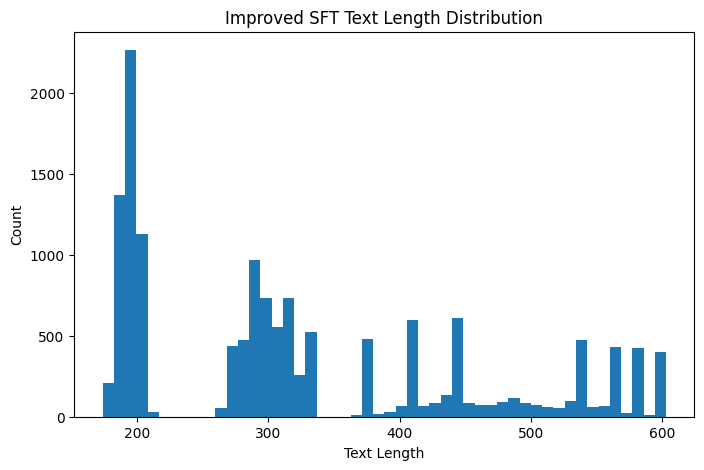

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(combined_df["text_length"], bins=50)
plt.title("Improved SFT Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.show()

Source distribution

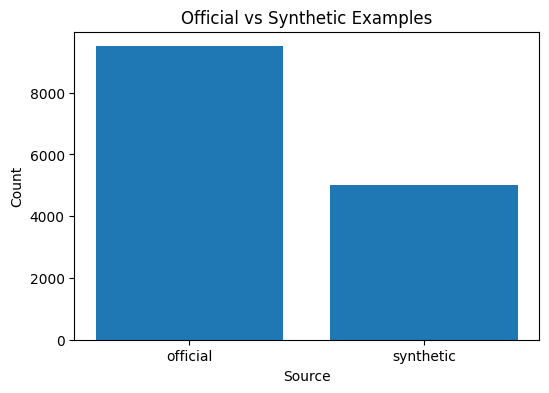

source
official     9500
synthetic    5000
Name: count, dtype: int64

In [22]:
source_counts = combined_df["source"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(source_counts.index, source_counts.values)
plt.title("Official vs Synthetic Examples")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()

display(source_counts)

In [23]:
train_sft_df, val_sft_df = train_test_split(
    combined_df,
    test_size=0.05,
    random_state=42,
    shuffle=True,
    stratify=combined_df["source"]
)

print("Train shape:", train_sft_df.shape)
print("Validation shape:", val_sft_df.shape)

print("\nTrain source distribution:")
display(train_sft_df["source"].value_counts())

print("\nValidation source distribution:")
display(val_sft_df["source"].value_counts())

Train shape: (13775, 7)
Validation shape: (725, 7)

Train source distribution:


source
official     9025
synthetic    4750
Name: count, dtype: int64


Validation source distribution:


source
official     475
synthetic    250
Name: count, dtype: int64

### Save

In [24]:
train_csv_path = PROCESSED_DATA_DIR / "improved_train_sft.csv"
val_csv_path = PROCESSED_DATA_DIR / "improved_val_sft.csv"
full_csv_path = PROCESSED_DATA_DIR / "improved_full_sft.csv"

train_sft_df.to_csv(train_csv_path, index=False)
val_sft_df.to_csv(val_csv_path, index=False)
combined_df.to_csv(full_csv_path, index=False)

print("Saved CSV files:")
print(train_csv_path)
print(val_csv_path)
print(full_csv_path)

Saved CSV files:
..\data\processed\improved_train_sft.csv
..\data\processed\improved_val_sft.csv
..\data\processed\improved_full_sft.csv


### Save JSON

In [25]:
train_jsonl_path = PROCESSED_DATA_DIR / "improved_train_sft.jsonl"
val_jsonl_path = PROCESSED_DATA_DIR / "improved_val_sft.jsonl"
full_jsonl_path = PROCESSED_DATA_DIR / "improved_full_sft.jsonl"

train_sft_df[["text"]].to_json(
    train_jsonl_path,
    orient="records",
    lines=True,
    force_ascii=False
)

val_sft_df[["text"]].to_json(
    val_jsonl_path,
    orient="records",
    lines=True,
    force_ascii=False
)

combined_df[["text"]].to_json(
    full_jsonl_path,
    orient="records",
    lines=True,
    force_ascii=False
)

print("Saved JSONL files:")
print(train_jsonl_path)
print(val_jsonl_path)
print(full_jsonl_path)

Saved JSONL files:
..\data\processed\improved_train_sft.jsonl
..\data\processed\improved_val_sft.jsonl
..\data\processed\improved_full_sft.jsonl


### Final Check

In [26]:
print("Processed files:")

for file in sorted(PROCESSED_DATA_DIR.iterdir()):
    print(file.name, round(file.stat().st_size / 1024, 2), "KB")

Processed files:
full_sft.csv 6710.46 KB
full_sft.jsonl 3902.32 KB
improved_full_sft.csv 8410.22 KB
improved_full_sft.jsonl 4984.42 KB
improved_train_sft.csv 7983.69 KB
improved_train_sft.jsonl 4732.05 KB
improved_val_sft.csv 426.59 KB
improved_val_sft.jsonl 252.37 KB
sft_train.jsonl 6983.7 KB
sft_val.jsonl 1238.41 KB
test_prompts.jsonl 3.56 KB
train_sft.csv 6368.81 KB
train_sft.jsonl 3704.01 KB
val_sft.csv 341.71 KB
val_sft.jsonl 198.3 KB


### Final Preview

In [27]:
preview_df = pd.read_json(full_jsonl_path, lines=True)

print("Preview shape:", preview_df.shape)
display(preview_df.head())

print("\nFirst training example:")
print(preview_df.loc[0, "text"])

Preview shape: (14500, 1)


,text
0,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01010001 -> 11011101\n00001001 -> 01101101\n00010101 -> 01010101\n11111111 -> 10000001\n10011101 -> 01000101\n00111011 -> 00001001\n10111101 -> 00000101\n00100110 -> 10110011\n\nNow, determine the output for: 00110100\n\nAnswer:\n10010111"
1,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n10001110 -> 00100110\n10011001 -> 01000100\n01100100 -> 00010001\n10000010 -> 00001010\n00011011 -> 01001100\n00111010 -> 10011100\n01101111 -> 00110111\n10010110 -> 01011010\n00001010 -> 00101100\n\nNow, determine the output for: 11100000\n\nAnswer:\n01000011"
2,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nucoov pwgtfyoqg vorq yrjjoe -> queen discovers near valley\npqrsfv pqorzg wvgwpo trgbjo -> dragon dreams inside castle\ngbcpovb tqorbog bxo zrswtrj pffq -> student creates the magical door\nbxo sfjpov pqrsfv dfjjfig -> the golden dragon follows\nnqwvtogg qorpg bxo zegboqwfcg gotqob -> princess reads the mysterious secret\nNow, decrypt the following text: trb wzrswvog hffk\n\nAnswer:\ncat imagines book"
3,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n11 -> XI\n15 -> XV\n94 -> XCIV\n19 -> XIX\nNow, write the number 38 in the Wonderland numeral system.\n\nAnswer:\nXXXVIII"
4,"You are solving a reasoning puzzle.\nReturn only the final answer.\n\nPuzzle:\nIn Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nwkgqa lsrqaq wneeke -> mouse chases mirror\nwkgqa nwrjnvaq nv brmrla -> mouse imagines in palace\nsrppae oerhq gvoae wkgvprnv -> hatter draws under mountain\npsa qaleap hncreo onqlkzaeq -> the secret wizard discovers\npsa hnqa xneo earoq -> the wise bird reads\nNow, decrypt the following text: hncreo learpaq qaleap\n\nAnswer:\nwizard creates secret"



First training example:
You are solving a reasoning puzzle.
Return only the final answer.

Puzzle:
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01010001 -> 11011101
00001001 -> 01101101
00010101 -> 01010101
11111111 -> 10000001
10011101 -> 01000101
00111011 -> 00001001
10111101 -> 00000101
00100110 -> 10110011

Now, determine the output for: 00110100

Answer:
10010111
